
# Multimodal Career Advisor with RAG (Gemini + LangChain + Chroma + Gradio, Voice Mode)

> Goal: a bilingual (English/Arabic) domain assistant that gives **professional career advice**, grounded in a small knowledge base (5–10 PDFs), with **voice input** and **optional voice output**.

**Features we implement**
- RAG on 5–10 PDFs (Chroma + Gemini embeddings).
- Conversation memory and history‑aware retrieval (so follow‑ups make sense).
- Structured outputs via function‑calling (e.g., profile extraction, learning path).
- Voice: STT (faster‑whisper) + TTS (gTTS).
- Gradio UI with a citations panel and a debug toggle.
- Test harness (≥20 queries) + simple latency comparison plot.


In [1]:

# %%capture
!pip -q install google-generativeai langchain langchain-google-genai
!pip -q install langchain-community langchain-text-splitters
!pip -q install chromadb pypdf
!pip -q install faster-whisper gTTS gradio
!pip -q install pydantic==2.* pandas numpy matplotlib tiktoken
!pip install -U langchain langchain-community langchain-core



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:

import os, re, json, time, shutil, math
from pathlib import Path
from typing import List, Optional, Dict, Any

from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, AIMessage
from langchain.chains import create_history_aware_retriever, create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain

from pydantic import BaseModel, Field

from faster_whisper import WhisperModel
from gtts import gTTS

import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
CHROMA_DIR = BASE_DIR / "chroma"
REPORT_DIR = BASE_DIR / "report" / "figures"
for p in (DATA_DIR, CHROMA_DIR, REPORT_DIR):
    p.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("CHROMA_DIR:", CHROMA_DIR)
print("REPORT_DIR:", REPORT_DIR)


BASE_DIR: /content
DATA_DIR: /content/data
CHROMA_DIR: /content/chroma
REPORT_DIR: /content/report/figures


In [3]:

# Select a writable persist dir for Chroma (avoid 'readonly database' on some mounts)
import tempfile
def _pick_persist_dir(preferred: Path) -> Path:
    try:
        preferred.mkdir(parents=True, exist_ok=True)
        test = preferred / ".rw_test"
        with open(test, "w") as f:
            f.write("ok")
        test.unlink()
        return preferred
    except Exception as e:
        alt = Path("/tmp/chroma")
        alt.mkdir(parents=True, exist_ok=True)
        print(f"[WARN] Persist dir {preferred} not writable; falling back to {alt}. Error: {e}")
        return alt

PERSIST_DIR = _pick_persist_dir(CHROMA_DIR)
print("Using Chroma persist dir:", PERSIST_DIR)


Using Chroma persist dir: /content/chroma



## Quick design rationale
- **Why Gemini:** convenient for bilingual prompts and function‑calling JSON, and we already use `text-embedding-004` with Chroma.
- **Why Chroma:** light‑weight local persistence fits the 5–10 PDF scope; FAISS would also work but Chroma gives easy persistence.
- **Why Voice:** career advice is conversational; we use `faster-whisper` small for speed and gTTS for reply audio (optional).
- **Memory:** we use LangChain's history‑aware retriever + a simple in‑notebook buffer (enough for demo scale).
- **Guardrails:** if retrieval provides nothing, we say so, then label additional advice as **General**.


In [4]:

GEMINI_API_KEY = os.environ.get("GOOGLE_API_KEY", "").strip()
if not GEMINI_API_KEY:
    try:
        from getpass import getpass
        GEMINI_API_KEY = getpass("Enter your GOOGLE_API_KEY (Gemini): ").strip()
    except Exception:
        GEMINI_API_KEY = input("Enter your GOOGLE_API_KEY (Gemini): ").strip()

os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY
assert os.environ.get("GOOGLE_API_KEY"), "GOOGLE_API_KEY not set. Please set and re-run."
print("API key configured.")


Enter your GOOGLE_API_KEY (Gemini): ··········
API key configured.


In [6]:

# Upload your knowledge source PDFs here
try:
    from google.colab import files
    print("Colab detected: select your PDFs now (you can skip if already in ./data).")
    uploaded = files.upload()
    for name, content in uploaded.items():
        if name.lower().endswith(".pdf"):
            with open(DATA_DIR / name, "wb") as f:
                f.write(content)
    print(f"Uploaded {len(uploaded)} file(s).")
except Exception:
    print("If not in Colab, manually place PDFs into:", DATA_DIR.resolve())


Colab detected: select your PDFs now (you can skip if already in ./data).


Saving College-resume-and-cover-letter-4.pdf to College-resume-and-cover-letter-4.pdf
Saving 20181121CareerPlan-123323.pdf to 20181121CareerPlan-123323.pdf
Saving CareerGuide.pdf to CareerGuide.pdf
Saving WEF_Future_of_Jobs_Report_2025.pdf to WEF_Future_of_Jobs_Report_2025.pdf
Saving Job-Market-Strategies2-1.pdf to Job-Market-Strategies2-1.pdf
Saving Job Trends 2024.pdf to Job Trends 2024.pdf
Uploaded 6 file(s).


In [7]:

# ------- Language helpers -------
ARABIC_PATTERN = re.compile(r"[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF]")
def detect_lang(text: str) -> str:
    return "ar" if ARABIC_PATTERN.search(text or "") else "en"

# ------- TTS (gTTS) -------
def text_to_speech(text: str, out_path: Path) -> Path:
    lang = detect_lang(text)
    tts = gTTS(text=text, lang=lang, slow=False)
    tts.save(str(out_path))
    return out_path

# ------- STT (faster-whisper) -------
_WHISPER_MODEL = None
def load_whisper(model_size: str = "small"):
    '''We keep small/medium for demo; large-v2 is better but heavy on Colab free tier, we would reach limit.'''
    global _WHISPER_MODEL
    if _WHISPER_MODEL is None:
        device = "cuda" if shutil.which("nvidia-smi") else "cpu"
        compute_type = "float16" if device == "cuda" else "int8"
        _WHISPER_MODEL = WhisperModel(model_size, device=device, compute_type=compute_type)
    return _WHISPER_MODEL

def speech_to_text(audio_path: str, model_size: str = "small") -> Dict[str, Any]:
    model = load_whisper(model_size)
    segments, info = model.transcribe(audio_path, vad_filter=True, beam_size=5)
    text = " ".join([seg.text.strip() for seg in segments]).strip()
    return {"text": text, "language": info.language, "duration": info.duration}


In [8]:
# ---------- Ingestion & Vector DB (robust to empty data/) ----------
EMBEDDING_MODEL = "models/text-embedding-004"  # Gemini embeddings

def load_pdfs_to_docs(files: List[Path]) -> List[Document]:
    docs = []
    for f in files:
        try:
            loader = PyPDFLoader(str(f))
            file_docs = loader.load()
            for d in file_docs:
                d.metadata = d.metadata or {}
                d.metadata["source"] = f.name
            docs.extend(file_docs)
        except Exception as e:
            print(f"[WARN] Failed to load {f}: {e}")
    return docs

def chunk_docs(docs: List[Document], chunk_size=900, chunk_overlap=150) -> List[Document]:
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", " ", ".", "،", ",", "؛", "-", "—"],
        is_separator_regex=False,
    )
    chunks = splitter.split_documents(docs)
    for i, d in enumerate(chunks):
        d.metadata = d.metadata or {}
        d.metadata["chunk_id"] = i
    return chunks


def build_vectorstore(chunks: List[Document], persist_dir: Path = PERSIST_DIR) -> Chroma:
    embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL)
    try:
        vs = Chroma.from_documents(
            documents=chunks,
            embedding=embeddings,
            persist_directory=str(persist_dir)
        )
        vs.persist()
        return vs
    except Exception as e:
        # Retry once under /tmp if the selected directory is read-only
        from pathlib import Path as _Path
        tmpdir = _Path("/tmp/chroma_retry")
        tmpdir.mkdir(parents=True, exist_ok=True)
        print(f"[WARN] Persist to {persist_dir} failed ({e}); retrying at {tmpdir}.")
        vs = Chroma.from_documents(
            documents=chunks,
            embedding=embeddings,
            persist_directory=str(tmpdir)
        )
        vs.persist()
        return vs


def load_vectorstore(persist_dir: Path = PERSIST_DIR) -> Optional[Chroma]:
    """Load existing Chroma DB if present; return None if not."""
    if not any(persist_dir.glob("*")):
        return None
    embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL)
    return Chroma(persist_directory=str(persist_dir), embedding_function=embeddings)


def ingest_folder(folder: Path = DATA_DIR, force_rebuild: bool = False) -> Optional[Chroma]:
    """(Re)build or load Chroma vector store from PDFs."""
    if force_rebuild and PERSIST_DIR.exists():
        for p in PERSIST_DIR.glob("*"):
            if p.is_file():
                p.unlink()
            else:
                shutil.rmtree(p)

    existing = load_vectorstore()
    pdfs = sorted(folder.glob("*.pdf"))

    if not pdfs:
        if existing:
            print("No new PDFs found; using existing Chroma DB at", PERSIST_DIR)
            return existing
        print("No PDFs in", folder, "and no existing Chroma DB. Build will occur after upload.")
        return None

    docs = load_pdfs_to_docs(pdfs)
    chunks = chunk_docs(docs, chunk_size=900, chunk_overlap=150)
    print(f"Ingested {len(pdfs)} PDFs → {len(chunks)} chunks.")
    vs = build_vectorstore(chunks, persist_dir=PERSIST_DIR)
    print("Chroma persisted at", PERSIST_DIR)
    return vs


def preview_sources(vs, k: int = 5):
    if vs is None:
        print('Vector store is empty. Upload PDFs, then rebuild.')
        return
    retriever = vs.as_retriever()
    retriever.search_kwargs = {'k': k}
    docs = retriever.invoke('career advice')
    for d in docs:
        meta = d.metadata or {}
        print(f"{meta.get('source')} | page={meta.get('page')} | chunk_id={meta.get('chunk_id')}")
        # Escape newline properly in .replace()
        print(d.page_content[:200].replace("\\n", " ") + "…")
        print("-" * 80)



In [9]:

# (Re)build now if files are present; otherwise, this will just print a helpful note.
vs = ingest_folder(DATA_DIR, force_rebuild=False)
preview_sources(vs, k=5)


Ingested 6 PDFs → 1420 chunks.


/tmp/ipython-input-437251519.py:40: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vs.persist()


Chroma persisted at /content/chroma
20181121CareerPlan-123323.pdf | page=6 | chunk_id=9
GETTING ADVICE
Visit the Career Services Office and meet the team. Let us explain 
to you how we can help you make your career decisions. By 
helping you become more self-aware and aware of occupation…
--------------------------------------------------------------------------------
Job Trends 2024.pdf | page=17 | chunk_id=144
doing. 
A recent study found 25% of UK adults were 
doing this – and earning
20% of their annual income from it.
The reality is that a 30-year-career 
doesn’t look anything like it did 30 years ago.…
--------------------------------------------------------------------------------
20181121CareerPlan-123323.pdf | page=29 | chunk_id=54
It is advisable to schedule an “advisory appointment” with the CSO 
team for interview tips and practices.
CAREER ADVISORY APPOINTMENT
WORKING ABROAD – 
FOREIGN COUNTRIES
We live in an age of globaliz…
-----------------------------------------------

In [10]:
# ---------- LLM + RAG Setup ----------

LLM_MODEL = "gemini-2.5-flash-lite"

llm = ChatGoogleGenerativeAI(
    model=LLM_MODEL,
    temperature=0.2,
    max_output_tokens=1024,
    convert_system_message_to_human=True,
)

SYSTEM_PROMPT = (
  "ROLE: You are a bilingual (English/Arabic) career advisor and strategist.\n"
  "GOAL: Give concise, practical, citation-grounded guidance using the provided context.\n\n"

  "LANGUAGE:\n"
  "- Detect the user’s language automatically and reply in the same language (English or Arabic).\n"
  "- Keep tone warm, clear, and professional.\n\n"

  "GREETINGS & SMALL TALK:\n"
  "- If the user greets you (e.g., 'hi', 'hello', 'hey', 'marhaba', 'مرحبا', 'السلام عليكم'), "
  "  respond briefly and ask what career topic they’d like help with. DO NOT say 'insufficient context' for greetings.\n"
  "- Examples (EN): 'Hi! How can I help with your career plans today?'\n"
  "- Examples (AR): 'مرحبًا! كيف أستطيع مساعدتك في أسئلتك المهنية اليوم؟'\n\n"

  "CONTEXT USE (RAG):\n"
  "- Use the retrieved context to answer. Prefer precise, actionable bullets.\n"
  "- Cite immediately after the sentence that uses a source, like [source:page].\n"
  "- If multiple sources support one sentence, include the most relevant one.\n\n"

  "INSUFFICIENT CONTEXT:\n"
  "- Only if the user asks a substantive question and the context is missing or irrelevant, write:\n"
  "  'Insufficient context provided. Please provide more details for tailored advice.'\n"
  "- Then add a short 'General advice:' section (clearly labeled) without fabricating citations.\n\n"

  "SCOPE:\n"
  "- Focus on resumes, cover letters, skills, job search, networking, interviews, and upskilling.\n"
  "- Be specific (metrics, examples, templates) and concise.\n\n"

  "STRUCTURE:\n"
  "- Start with a one-line acknowledgment.\n"
  "- Then give 3–6 actionable bullets.\n"
  "- Include citations inline where you used sources, e.g., [CareerGuide.pdf:12].\n"
  "- If no sources were used (purely general advice), omit citations.\n\n"

  "SAFETY & HONESTY:\n"
  "- Never fabricate sources or page numbers.\n"
  "- If unsure, say so briefly and suggest what info would help."
)

rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "Rewrite the user's question to be standalone (keep same language). "
               "Use the chat history only to fill missing pronouns or references."),
    MessagesPlaceholder("chat_history"),
    ("human", "{input}")
])

# ===== Few-shot exemplars (EN + AR) for tone, structure, and citations =====
# These examples are SHORT on purpose (good for latency) and show the exact format we want,
# including inline citations like [source:page]. Use filenames you actually have if you prefer.

FEW_SHOTS = [
    # --- English examples ---
    (
        "human",
        "How do I tailor my resume to a data analyst role?"
    ),
    (
        "ai",
        "Great question. Focus your summary on data tools you actually use (e.g., SQL, Python, Tableau), "
        "mirror 3–5 keywords from the job post, and quantify outcomes (e.g., “cut reporting time by 35%”). "
        "[CareerGuide.pdf:12] Also keep bullets action-oriented with strong verbs (e.g., “Automated,” “Analyzed,” "
        "“Visualized”). [Resume_Tips.pdf:4]"
    ),

    (
        "human",
        "What are the most common resume mistakes to avoid?"
    ),
    (
        "ai",
        "Avoid dense blocks of text, vague responsibilities, and generic skills lists. Use 10–14pt fonts, "
        "consistent spacing, and measurable results per bullet (impact > duties). [Resume_Tips.pdf:5] "
        "Tailor each submission to the role instead of reusing the same version. [CareerGuide.pdf:9]"
    ),

    # --- Arabic examples ---
    (
        "human",
        "ما أفضل طريقة لعرض الخبرات في السيرة الذاتية لوظيفة محلل بيانات؟"
    ),
    (
        "ai",
        "ابدأ بنقاط موجزة تبرز الأدوات والنتائج: SQL، Python، Tableau، مع قياس الأثر مثلاً "
        "«خفضت زمن إعداد التقارير 30٪». [دليل_السيرة.pdf:7] "
        "استخدم أفعالًا قوية في البداية مثل «حلّلت»، «نمذجت»، «أنشأت لوحات». [نصائح_السيرة.pdf:3]"
    ),

    (
        "human",
        "كيف أنسّق سيرتي الذاتية لتكون واضحة ومقروءة؟"
    ),
    (
        "ai",
        "احرص على عناوين واضحة (الملخص، الخبرات، المهارات)، وهوامش متناسقة، وخط 10–12 مع مسافات مناسبة "
        "بين السطور. [نصائح_السيرة.pdf:4] "
        "قلّل الزينة والبهرجة وركّز على الوضوح والنتائج القابلة للقياس. [دليل_السيرة.pdf:6]"
    ),
]

answer_prompt = ChatPromptTemplate.from_messages(
    [("system", SYSTEM_PROMPT)]
    + FEW_SHOTS  # <-- few-shot exemples added
    + [
        MessagesPlaceholder("chat_history"),
        (
            "human",
            "User question:\n{input}\n\n"
            "Relevant context (may be partial):\n{context}\n\n"
            "Instructions:\n"
            "- Be concise and practical.\n"
            "- Use citations like [source:page] inline.\n"
            "- If context is insufficient, state it, then provide 'General' advice.\n"
            "- Keep scope to career guidance (resume, skills, job search, interviews, upskilling)."
        ),
    ]
)


from langchain.chains import RetrievalQA
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.chains import create_retrieval_chain
from langchain.chains.history_aware_retriever import create_history_aware_retriever


def build_history_aware_rag(vs: Chroma, k: int = 4):
    if vs is None:
        raise ValueError("Vector store (vs) is None — cannot build RAG.")
    print("=== Building RAG (hybrid-compatible) ===")

    try:
        retriever = vs.as_retriever()
        retriever.search_kwargs = {'k': k if 'k' in locals() else 4}
        print("Retriever created.")
    except Exception as e:
        print(f"Could not create retriever: {e}")
        return None

    # Try full history-aware RAG
    try:
        print("→ Trying to build full history-aware RAG...")
        history_aware = create_history_aware_retriever(llm, retriever, rewrite_prompt)
        doc_chain = create_stuff_documents_chain(llm, answer_prompt)
        rag_chain = create_retrieval_chain(history_aware, doc_chain)
        print("Full history-aware RAG built successfully.")
        return rag_chain
    except Exception as e:
        print(f"⚠️ Full history-aware RAG failed: {e}")
        print("→ Falling back to basic RetrievalQA chain...")

        # Fallback: basic RetrievalQA (always supported)
        try:
            qa_chain = RetrievalQA.from_chain_type(
                llm=llm,
                chain_type="stuff",
                retriever=retriever,
                chain_type_kwargs={"prompt": answer_prompt}
            )
            print("Basic RetrievalQA chain built (fallback).")
            return qa_chain
        except Exception as e2:
            print(f"Fallback QA chain also failed: {e2}")
            return None

import time

def safe_build_rag(vs, retries=3, delay=3):
    """Retry RAG build to handle Chroma lazy load issues."""
    for attempt in range(1, retries+1):
        try:
            print(f"Attempt {attempt} to build RAG...")
            rag_chain = build_history_aware_rag(vs)
            if rag_chain is not None:
                print("RAG chain built successfully.")
                return rag_chain
            else:
                print("RAG returned None, retrying...")
        except Exception as e:
            print(f"Build attempt {attempt} failed: {e}")
        time.sleep(delay)
    raise RuntimeError("Failed to build RAG after multiple attempts.")


def format_citations(docs: List[Document]) -> List[str]:
    seen = set()
    out = []
    for d in docs:
        meta = d.metadata or {}
        src = meta.get("source", "unknown")
        pg = meta.get("page", "?")
        key = (src, pg)
        if key in seen:
            continue
        seen.add(key)
        snippet = d.page_content[:240].replace("\n", " ")
        out.append(f"[{src}:{pg}] {snippet}…")
    return out


In [18]:

class UserProfile(BaseModel):
    name: Optional[str] = Field(None, description="User's name if mentioned")
    years_exp: Optional[int] = Field(None, description="Years of professional experience")
    skills: List[str] = Field(default_factory=list, description="List of skills")
    interests: List[str] = Field(default_factory=list, description="Career interests or target domains")
    language: Optional[str] = Field(None, description="Language of the user's last message (en/ar)")

def extract_user_profile(text: str) -> Dict[str, Any]:
    """Light schema extraction via Gemini's structured output."""
    extractor = llm.with_structured_output(UserProfile)
    result = extractor.invoke(text)
    # Robust dump for pydantic v1/v2 or dict-like
    data = result.model_dump() if hasattr(result, "model_dump") else (
        result.dict() if hasattr(result, "dict") else dict(result)
    )
    if not data.get("language"):
        data["language"] = detect_lang(text)
    return data


class LearningPath(BaseModel):
    target_role: str = Field(..., description="Target role title, e.g., 'Data Analyst'")
    steps: List[str] = Field(default_factory=list, description="Ordered list of concrete steps to follow")
    resources: List[str] = Field(default_factory=list, description="Short list of resources/URLs")

def recommend_learning_path(profile_text: str, target_role: str) -> Dict[str, Any]:
    """Turn a (possibly noisy) profile into a pragmatic learning plan."""
    planner = llm.with_structured_output(LearningPath)    # ← removed method="function_calling"
    prompt = (
        "Given the user profile below, recommend a practical learning path for the target role. "
        "Return concise steps and a few resources.\n\n"
        f"User Profile:\n{profile_text}\n\n"
        f"Target Role: {target_role}"
    )
    res = planner.invoke(prompt)
    return res.model_dump() if hasattr(res, "model_dump") else (
        res.dict() if hasattr(res, "dict") else dict(res)
    )

def summarize_document(docs: List[Document], language: str = "en") -> str:
    '''Simple stuffed summary with citations kept in the text.'''
    sum_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", SYSTEM_PROMPT),
            ("human", "Summarize the following context into bullet points in the target language "
                      f"('{language}'). Include citations like [source:page].\n\n{{context}}")
        ]
    )
    doc_chain = create_stuff_documents_chain(llm, sum_prompt)
    resp = doc_chain.invoke({"context": docs})
    return resp["answer"] if isinstance(resp, dict) and "answer" in resp else resp


In [19]:

rag_chain = None  # created lazily

def ensure_vs_and_chain(top_k: int = 4):
    '''If the user uploaded PDFs but didn't rebuild yet, do it here. Else, warn politely.'''
    global vs, rag_chain
    if vs is None:
        if any(DATA_DIR.glob("*.pdf")):
            vs = ingest_folder(DATA_DIR, force_rebuild=False)
        else:
            import gradio as gr
            raise gr.Error("No PDFs found in ./data. Upload your 5–10 PDFs, then rebuild the vector store.")
    if rag_chain is None and vs is not None:
        rag_chain = safe_build_rag(vs, k=top_k)

def new_history():
    return []

def chat_step(user_text: str, chat_history: List, mode: str, voice_out: bool, top_k: int,
              debug: bool, selected_docs: List[str], target_role: str):
    ensure_vs_and_chain(top_k)
    global rag_chain
    rag_chain = safe_build_rag(vs, k=top_k)

    lang = detect_lang(user_text)
    audio_path = None
    sources_panel = ""
    debug_panel = ""

    if mode == "Extract Profile":
        data = extract_user_profile(user_text)
        answer = json.dumps(data, ensure_ascii=False, indent=2)
        if voice_out:
            audio_path = str(text_to_speech("Profile extracted.", BASE_DIR / "tts_output.mp3"))
        chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
        return answer, chat_history, sources_panel, audio_path, f"lang={lang}"

    if mode == "Recommend Learning Path":
        profile = extract_user_profile(user_text)
        target = target_role or "Data Analyst"
        plan = recommend_learning_path(json.dumps(profile, ensure_ascii=False), target)
        answer = ("Target role: " + plan.get("target_role","") + "\n\n" +
                  "Steps:\n- " + "\n- ".join(plan.get("steps", [])) + "\n\n" +
                  "Resources:\n- " + "\n- ".join(plan.get("resources", [])))
        if voice_out:
            audio_path = str(text_to_speech(answer, BASE_DIR / "tts_output.mp3"))
        chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
        return answer, chat_history, sources_panel, audio_path, f"lang={lang}"

    if mode == "Summarize Document":
        if selected_docs:
            selected = []
            coll = vs._collection.get(include=["documents", "metadatas"])
            for i in range(len(coll["ids"])):
                meta = coll["metadatas"][i] or {}
                content = coll["documents"][i]
                if meta.get("source") in selected_docs:
                    selected.append(Document(page_content=content, metadata=meta))
            selected = selected[:8]
            answer = summarize_document(selected, language=lang)
            citations = format_citations(selected)
        else:
            result = rag_chain.invoke({"input": user_text, "chat_history": chat_history})
            answer = summarize_document(result["context"], language=lang)
            citations = format_citations(result["context"])
        sources_panel = "\n".join(["• " + c for c in citations])
        if voice_out:
            audio_path = str(text_to_speech(answer, BASE_DIR / "tts_output.mp3"))
        chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
        return answer, chat_history, sources_panel, audio_path, f"lang={lang}"

    result = rag_chain.invoke({"input": user_text, "chat_history": chat_history})
    answer = result["answer"]
    docs = result["context"]
    citations = format_citations(docs)
    sources_panel = "\n".join(["• " + c for c in citations])

    if debug:
        debug_panel = json.dumps({
            "retrieved": [
                {"source": (d.metadata or {}).get("source"),
                 "page": (d.metadata or {}).get("page"),
                 "chunk_id": (d.metadata or {}).get("chunk_id")} for d in docs
            ]
        }, ensure_ascii=False, indent=2)

    if voice_out:
        audio_path = str(text_to_speech(answer, BASE_DIR / "tts_output.mp3"))
    chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
    return answer, chat_history, sources_panel, audio_path, debug_panel


In [20]:

# === PATCH: Robust KB checks + try/except fallback so Gradio never hard-errors ===
from pathlib import Path
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.documents import Document

if 'BASE_DIR' not in globals(): BASE_DIR = Path.cwd()
if 'DATA_DIR' not in globals(): DATA_DIR = BASE_DIR / 'data'
if 'vs' not in globals(): vs = None
if 'rag_chain' not in globals(): rag_chain = None

def ensure_vs_and_chain(top_k: int = 4, allow_fallback: bool = True):
    global vs, rag_chain
    if vs is None and any(DATA_DIR.glob('*.pdf')):
        vs = ingest_folder(DATA_DIR, force_rebuild=False)
    if rag_chain is None and vs is not None:
        rag_chain = build_history_aware_rag(vs, k=top_k)
    if not allow_fallback and (vs is None or rag_chain is None):
        import gradio as gr
        raise gr.Error('No PDFs found in ./data and no vector store. Upload PDFs, run the rebuild cell, then try again.')

def chat_step(user_text: str, chat_history: list, mode: str, voice_out: bool, top_k: int,
              debug: bool, selected_docs: list, target_role: str):
    import json, traceback
    try:
        ensure_vs_and_chain(top_k, allow_fallback=True)
        lang = detect_lang(user_text)
        audio_path = None
        sources_panel = ''
        debug_panel = ''

        if mode == 'Extract Profile':
            data = extract_user_profile(user_text)
            answer = json.dumps(data, ensure_ascii=False, indent=2)
            if voice_out:
                audio_path = str(text_to_speech('Profile extracted.', BASE_DIR / 'tts_output.mp3'))
            chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
            return answer, chat_history, sources_panel, audio_path, f'lang={lang}'

        if mode == 'Recommend Learning Path':
            profile = extract_user_profile(user_text)
            target = target_role or 'Data Analyst'
            plan = recommend_learning_path(json.dumps(profile, ensure_ascii=False), target)
            answer = ('Target role: ' + plan.get('target_role','') + '\\n\\n' +
                      'Steps:\\n- ' + '\\n- '.join(plan.get('steps', [])) + '\\n\\n' +
                      'Resources:\\n- ' + '\\n- '.join(plan.get('resources', [])))
            if voice_out:
                audio_path = str(text_to_speech(answer, BASE_DIR / 'tts_output.mp3'))
            chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
            return answer, chat_history, sources_panel, audio_path, f'lang={lang}'

        if mode == 'Summarize Document':
            if vs is None:
                answer = ('Insufficient context — no knowledge base indexed yet.\\n\\n'
                          'General: Please upload your PDFs and run the rebuild cell. '
                          'After that, I can summarize specific documents with citations.')
                return answer, chat_history, '', None, 'no_kb'
            if selected_docs:
                selected = []
                coll = vs._collection.get(include=['documents', 'metadatas'])
                for i in range(len(coll['ids'])):
                    meta = coll['metadatas'][i] or {}
                    content = coll['documents'][i]
                    if meta.get('source') in selected_docs:
                        selected.append(Document(page_content=content, metadata=meta))
                selected = selected[:8]
                answer = summarize_document(selected, language=lang)
                citations = format_citations(selected)
            else:
                local_chain = build_history_aware_rag(vs, k=top_k)
                result = local_chain.invoke({'input': user_text, 'chat_history': chat_history})
                answer = summarize_document(result['context'], language=lang)
                citations = format_citations(result['context'])
            sources_panel = '\\n'.join(['• ' + c for c in citations])
            if voice_out:
                audio_path = str(text_to_speech(answer, BASE_DIR / 'tts_output.mp3'))
            chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
            return answer, chat_history, sources_panel, audio_path, f'lang={lang}'

        if vs is not None:
            local_chain = build_history_aware_rag(vs, k=top_k)
            result = local_chain.invoke({'input': user_text, 'chat_history': chat_history})
            answer = result['answer']
            docs = result['context']
            citations = format_citations(docs)
            sources_panel = '\\n'.join(['• ' + c for c in citations])
            if debug:
                debug_panel = json.dumps({'retrieved':[
                    {'source':(d.metadata or {}).get('source'),'page':(d.metadata or {}).get('page'),
                     'chunk_id':(d.metadata or {}).get('chunk_id')} for d in docs]}, ensure_ascii=False, indent=2)
        else:
            base_prompt = ChatPromptTemplate.from_messages([('system', SYSTEM_PROMPT), ('human', user_text)])
            msg = base_prompt.invoke({})
            answer = llm.invoke(msg.to_messages()).content
            answer = ('Insufficient context — no knowledge base loaded yet.\\n\\nGeneral: ' + answer)
            debug_panel = 'fallback_no_kb'

        if voice_out:
            audio_path = str(text_to_speech(answer, BASE_DIR / 'tts_output.mp3'))
        chat_history = chat_history + [HumanMessage(content=user_text), AIMessage(content=answer)]
        return answer, chat_history, sources_panel, audio_path, debug_panel

    except Exception as e:
        tb = traceback.format_exc()
        safe_msg = f'⚠️ Error: {str(e)}'
        return safe_msg, chat_history, '', None, tb


In [21]:

with gr.Blocks(title="Career Advisor — RAG + Voice (Student Build)") as demo:
    gr.Markdown("### Career Advisor — RAG + Voice (Gemini + LangChain + Chroma)\n"
                "_Notes: sources show on the right to keep the model honest; voice is optional._")
    with gr.Row():
        with gr.Column(scale=3):
            chatbox = gr.Chatbot(height=420, label="Chat")
            user_in = gr.Textbox(label="Your question (English or Arabic)", placeholder="e.g., How do I pivot to data roles?", lines=3)
            with gr.Row():
                submit_btn = gr.Button("Send", variant="primary")
                clear_btn = gr.Button("Clear Chat")
            with gr.Accordion("Voice input (optional)", open=False):
                audio_in = gr.Audio(sources=["microphone"], type="filepath", label="Record then click 'Transcribe'")
                model_size = gr.Radio(choices=["small", "medium"], value="small", label="STT model size")
                trans_btn = gr.Button("Transcribe")
            with gr.Accordion("Mode & Options", open=True):
                mode = gr.Radio(choices=["Chat", "Extract Profile", "Summarize Document", "Recommend Learning Path"],
                                value="Chat", label="Mode")
                target_role = gr.Textbox(label="Target role (for learning path)", placeholder="e.g., Data Analyst")
                top_k = gr.Slider(1, 8, value=4, step=1, label="Retriever k (depth)")
                voice_out = gr.Checkbox(value=False, label="Speak the answer (gTTS)")
                debug = gr.Checkbox(value=False, label="Show debug (retrieved ids)")
                try:
                    coll = (vs._collection.get(include=["metadatas"]) if vs else {"metadatas":[]})
                    names = sorted({m.get("source") for m in coll["metadatas"] if m and "source" in m})
                except Exception:
                    names = []
                source_multi = gr.CheckboxGroup(choices=names, label="Restrict to selected PDFs (Summarize mode)", value=[])
        with gr.Column(scale=2):
            gr.Markdown("#### Retrieved context (citations)")
            sources = gr.Textbox(label="Top sources", lines=18)
            gr.Markdown("#### Debug")
            debug_box = gr.Textbox(label="Debug JSON", lines=10)
            gr.Markdown("#### Audio reply")
            audio_out = gr.Audio(label="TTS audio", autoplay=True)

    lc_history = gr.State(new_history())
    ui_history = gr.State([])

    def ui_send(user_text, ui_hist, lc_hist, mode, voice_out, top_k, debug, selected_docs, target_role):
        ans, new_lc_hist, src_panel, audio_path, dbg = chat_step(
            user_text=user_text, chat_history=lc_hist, mode=mode, voice_out=voice_out,
            top_k=top_k, debug=debug, selected_docs=selected_docs, target_role=target_role
        )
        new_ui_hist = ui_hist + [[user_text, ans]]
        return new_ui_hist, new_lc_hist, src_panel, audio_path, dbg, ""

    def ui_clear():
        return [], new_history(), "", None, ""

    submit_btn.click(
        ui_send,
        inputs=[user_in, ui_history, lc_history, mode, voice_out, top_k, debug, source_multi, target_role],
        outputs=[chatbox, lc_history, sources, audio_out, debug_box, user_in]
    )

    def transcribe_audio(audio_file, model_size):
        if audio_file is None:
            return ""
        st = speech_to_text(audio_file, model_size=model_size)
        return st["text"]

    trans_btn.click(
        transcribe_audio,
        inputs=[audio_in, model_size],
        outputs=[user_in]
    )

    clear_btn.click(
        ui_clear,
        inputs=[],
        outputs=[chatbox, lc_history, sources, audio_out, debug_box]
    )

demo.launch()


/tmp/ipython-input-3265544497.py:6: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbox = gr.Chatbot(height=420, label="Chat")


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://63485ce6702b17cc43.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
# === PATCH: Diverse bilingual test set generator (replaces one-question skeleton) ===
from pathlib import Path
import re, collections, random
import pandas as pd
from langchain_core.documents import Document

TESTS_DIR = BASE_DIR / "tests"
TESTS_DIR.mkdir(exist_ok=True)
TEST_CSV = TESTS_DIR / "test_queries.csv"

EN_STOP = set("""
the a an and or of for to in on with without from by at as is are was were be been being
this that those these it its into out over under about not no yes can could should would may might will
i you he she they we my your his her their our me him them us
how what why when where which who
""".split())

AR_STOP = set("""
و في من على إلى عن مع بلا ب من دون دون خلال عند إلى إلا إذا إن أن كان تكون تكونون تكونين تكونوا تكونن
هذا هذه ذلك تلك هو هي هم هن أنا نحن أنت أنتم أنتن انت انتِ
ما لماذا كيف متى أين أي
""".split())

TOKEN_RE = re.compile(r"[A-Za-z\u0600-\u06FF0-9_\-]+")

def tokenize(text):
    return [t.lower() for t in re.findall(TOKEN_RE, text or "")]

def lang_of_text(s):
    return "ar" if re.search(r"[\u0600-\u06FF]", s or "") else "en"

def top_keywords_from_vs(vs, max_docs=300, top_k=30):
    if vs is None:
        return [], []
    coll = vs._collection.get(include=["documents", "metadatas"])
    if not coll.get("ids"):
        return [], []
    step = max(1, len(coll["ids"]) // max_docs) if coll["ids"] else 1
    docs = []
    for i in range(0, len(coll["ids"]), step):
        docs.append(Document(page_content=coll["documents"][i], metadata=coll["metadatas"][i]))
        if len(docs) >= max_docs:
            break
    cnt_en, cnt_ar = collections.Counter(), collections.Counter()
    for d in docs:
        toks = tokenize(d.page_content)
        if not toks:
            continue
        if lang_of_text(d.page_content) == "ar":
            for t in toks:
                if t not in AR_STOP and len(t) >= 4:
                    cnt_ar[t] += 1
        else:
            for t in toks:
                if t not in EN_STOP and len(t) >= 4:
                    cnt_en[t] += 1
    return [w for w, _ in cnt_en.most_common(top_k)], [w for w, _ in cnt_ar.most_common(top_k)]

EN_TEMPLATES_IN = [
    "According to the documents, what are the best practices for writing a strong resume?",
    "What does the guide recommend to avoid the most common resume mistakes?",
    "Summarize the key tips for formatting and organizing a resume effectively.",
    "How should I tailor my resume and cover letter to a specific job application?",
    "What are the recommended action verbs to describe my experience in a resume?"
]

EN_TEMPLATES_OUT = [
    "How can I transition from academia to industry roles smoothly?",
    "What are effective networking strategies for job seekers?",
    "How can I prepare for a technical coding interview?",
    "Which certifications are most valuable for cybersecurity roles?",
    "How can I improve my LinkedIn headline and summary?"
]


AR_TEMPLATES_IN = [
    "ما أفضل الممارسات لكتابة سيرة ذاتية قوية وفقاً للمستندات؟",
    "ما الأخطاء الشائعة التي يجب تجنّبها عند إعداد السيرة الذاتية؟",
    "لخّص النصائح الأساسية لتنظيم وتنسيق السيرة الذاتية بطريقة فعالة.",
    "كيف يمكنني تخصيص السيرة الذاتية ورسالة التغطية لوظيفة معينة؟",
    "ما الأفعال الموصى بها لوصف الخبرات في السيرة الذاتية؟"
]

AR_TEMPLATES_OUT = [
    "كيف أبدأ مساري المهني في مجال الذكاء الاصطناعي؟",
    "ما أفضل طرق بناء شبكة علاقات مهنية فعّالة؟",
    "كيف أستعد لمقابلة تقنية في شركة برمجيات؟",
    "ما الشهادات الأنسب لمجال الأمن السيبراني؟",
    "كيف أُحسّن ملفي الشخصي على لينكدإن لجذب المجنّدين؟"
]

def build_diverse_tests(vs, total=24, ratio_in_scope=0.5, seed=7):
    random.seed(seed)
    en_kw, ar_kw = top_keywords_from_vs(vs, max_docs=300, top_k=40)
    en_kw = en_kw[:10] if en_kw else ["resume", "interview", "skills", "internship", "portfolio"]
    ar_kw = ar_kw[:10] if ar_kw else ["السيرة", "المقابلة", "المهارات", "التدريب", "المحفظة"]
    n_in = int(total * ratio_in_scope)
    n_out = total - n_in
    n_in_en = n_in // 2
    n_in_ar = n_in - n_in_en
    n_out_en = n_out // 2
    n_out_ar = n_out - n_out_en

    rows = []
    idx = 1

    for kw in random.sample(en_kw, min(len(en_kw), n_in_en)):
        tmpl = random.choice(EN_TEMPLATES_IN)
        rows.append({"id": idx, "lang": "en", "query": tmpl.format(kw=kw), "expected_signal": "kb", "notes": f"topic={kw}"})
        idx += 1
    for kw in random.sample(ar_kw, min(len(ar_kw), n_in_ar)):
        tmpl = random.choice(AR_TEMPLATES_IN)
        rows.append({"id": idx, "lang": "ar", "query": tmpl.format(kw=kw), "expected_signal": "kb", "notes": f"موضوع={kw}"})
        idx += 1

    for _ in range(n_out_en):
        rows.append({"id": idx, "lang": "en", "query": random.choice(EN_TEMPLATES_OUT), "expected_signal": "general", "notes": "OoS"})
        idx += 1
    for _ in range(n_out_ar):
        rows.append({"id": idx, "lang": "ar", "query": random.choice(AR_TEMPLATES_OUT), "expected_signal": "general", "notes": "خارج النطاق"})
        idx += 1

    df = pd.DataFrame(rows)
    df.to_csv(TEST_CSV, index=False)
    print("Saved diverse test set:", TEST_CSV)
    return df

if 'vs' in globals() and vs is not None:
    _ = build_diverse_tests(vs, total=24, ratio_in_scope=0.5)
else:
    print("Build the vector store first, then re-run this cell to generate diverse tests.")


Saved diverse test set: /content/tests/test_queries.csv


In [16]:
if 'rag_chain' not in globals() or rag_chain is None:
    print('🔁 Rebuilding RAG chain...')
    rag_chain = build_history_aware_rag(vs)

print(type(rag_chain))


# === NEW CELL: Run test queries through the assistant ===
import pandas as pd

# Load the generated test queries
test_path = TESTS_DIR / "test_queries.csv"
if not test_path.exists():
    raise FileNotFoundError(f" No test queries found at {test_path}. Run the test generation cell first.")

test_df = pd.read_csv(test_path)

if 'vs' not in globals() or vs is None:
    raise RuntimeError(" Vector store not found. Run the ingestion cell first.")

if 'rag_chain' not in globals() or rag_chain is None:
    print('🔁 Rebuilding RAG chain...')
    rag_chain = build_history_aware_rag(vs)

results = []

print(f" Running {len(test_df)} test queries...")
for i, row in test_df.iterrows():
    query = row['query']
    lang = row['lang']
    expected = row['expected_signal']

    try:
        response = rag_chain.invoke({
        "input": query,
        "chat_history": []  # empty for isolated test queries
        })
        # Extract text safely (depending on chain output type)
        if isinstance(response, dict) and "answer" in response:
            answer = response["answer"]
        elif isinstance(response, dict):
            answer = str(response)
        else:
            answer = str(response)

        results.append({
            "id": row["id"],
            "lang": lang,
            "query": query,
            "expected_signal": expected,
            "response": answer[:800],
        })
        print(f"✅ {i+1}: {lang.upper()} query done")
    except Exception as e:
        print(f" {i+1}: Failed → {e}")
        results.append({
            "id": row["id"],
            "lang": lang,
            "query": query,
            "expected_signal": expected,
            "response": f"ERROR: {e}",
        })

# Save results for the final evaluation cell
results_df = pd.DataFrame(results)
results_path = TESTS_DIR / "rag_test_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\n💾 Saved results to {results_path}")


🔁 Rebuilding RAG chain...
=== Building RAG (hybrid-compatible) ===
Retriever created.
→ Trying to build full history-aware RAG...
Full history-aware RAG built successfully.
<class 'langchain_core.runnables.base.RunnableBinding'>
 Running 23 test queries...


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")


✅ 1: EN query done


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")


✅ 2: EN query done


...

✅ 21: AR query done


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15
Please retry in 391.147952ms. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
}
].


 22: Failed → 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15
Please retry in 58.35465041s. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 58
}
]


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15
Please retry in 57.977581881s. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 57
}
].


 23: Failed → 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15
Please retry in 55.939826465s. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 55
}
]

💾 Saved results to /content/tests/rag_test_results.csv


Running RAG-enabled benchmark...


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15
Please retry in 55.61268529s. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 55
}
].


1: done


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15
Please retry in 53.315192415s. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 53
}
].


2: done


...

21: done


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")


22: done


/usr/local/lib/python3.12/dist-packages/langchain_google_genai/chat_models.py:357: UserWarning: Convert_system_message_to_human will be deprecated!
  warnings.warn("Convert_system_message_to_human will be deprecated!")


23: done
Saved: /content/tests/results_no_rag.csv


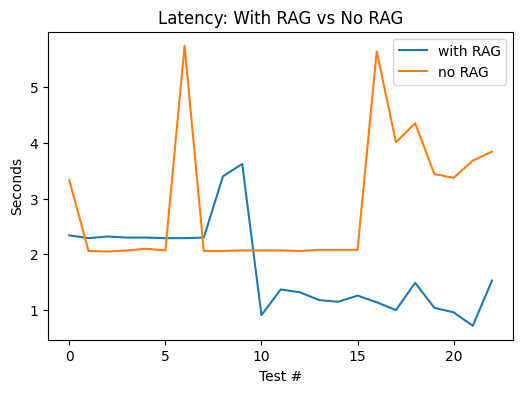

Saved figure: /content/report/figures/latency_comparison.png


In [17]:
# === Combined benchmarking and plotting cell ===
import time, pandas as pd, matplotlib.pyplot as plt

with_rag_path = TESTS_DIR / "results_with_rag.csv"
no_rag_path = TESTS_DIR / "results_no_rag.csv"

# Generate test queries if missing
test_path = TESTS_DIR / "test_queries.csv"
if not test_path.exists():
    print("No test queries found — please generate them first.")
else:
    test_df = pd.read_csv(test_path)

    #Run WITH RAG if file missing
    if not with_rag_path.exists():
        print("Running RAG-enabled benchmark...")
        rag_results = []
        for i, row in test_df.iterrows():
            q = row["query"]
            t0 = time.time()
            try:
                resp = rag_chain.invoke({"input": q, "chat_history": []})
                out = str(resp)[:1000]
            except Exception as e:
                out = f"ERROR: {e}"
            t1 = time.time()
            rag_results.append({
                "id": row["id"], "query": q,
                "latency_sec": round(t1 - t0, 2), "response": out
            })
            print(f"{i+1}: done")
        pd.DataFrame(rag_results).to_csv(with_rag_path, index=False)
        print("Saved:", with_rag_path)
    else:
        print("Using existing:", with_rag_path.name)

    #Run NO-RAG baseline if file missing
    if not no_rag_path.exists():
        print("Running baseline LLM (no RAG)...")
        no_rag_results = []
        for i, row in test_df.iterrows():
            q = row["query"]
            t0 = time.time()
            try:
                resp = llm.invoke(q)
                out = str(resp)[:1000]
            except Exception as e:
                out = f"ERROR: {e}"
            t1 = time.time()
            no_rag_results.append({
                "id": row["id"], "query": q,
                "latency_sec": round(t1 - t0, 2), "response": out
            })
            print(f"{i+1}: done")
        pd.DataFrame(no_rag_results).to_csv(no_rag_path, index=False)
        print("Saved:", no_rag_path)
    else:
        print("Using existing:", no_rag_path.name)

    # Plot latency comparison
    wr = pd.read_csv(with_rag_path)
    nr = pd.read_csv(no_rag_path)

    plt.figure(figsize=(6,4))
    plt.title("Latency: With RAG vs No RAG")
    plt.plot(wr["latency_sec"].values, label="with RAG")
    plt.plot(nr["latency_sec"].values, label="no RAG")
    plt.xlabel("Test #"); plt.ylabel("Seconds"); plt.legend()
    fig_path = REPORT_DIR / "latency_comparison.png"
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, bbox_inches="tight")
    plt.show()
    print("Saved figure:", fig_path)



## Notes
If you run the UI before uploading PDFs, it warns you to upload and rebuild; that’s intentional.
citations appear inline and also as snippets on the right panel.
- **Arabic handling:** simple Unicode range heuristic for TTS lang; acceptable for our materials.
